## Introduction to contour lines

This notebook introduces the two main ways to draw contour lines in
earthkit-plots:

- `ekp.geo.contour` – the high-level, single-call API
- `Map.contour` – the lower-level API that gives you full control over
  the map and lets you layer multiple plots

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

data = ekd.from_source("sample", "era5-2t-msl-1985122512.grib").to_fieldlist()
pressure = data.sel({"parameter.variable": "msl"})
temperature = data.sel({"parameter.variable": "2t"})

### High-level API: `ekp.geo.contour`

The simplest way to draw contour lines is with `ekp.geo.contour`.
By default it uses the plasma colour map and automatically picks
sensible contour levels.

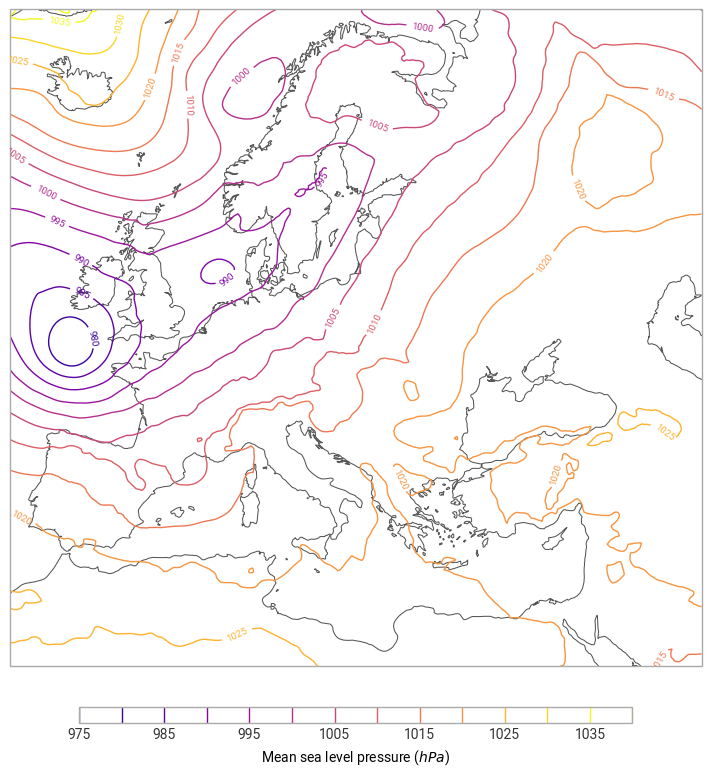

In [2]:
ekp.geo.contour(pressure, units="hPa", domain="Europe")

### Automatic styles with `style="auto"`

For well-known meteorological variables earthkit-plots has pre-defined
styles.  Pass `style="auto"` and it will select the appropriate one
automatically.

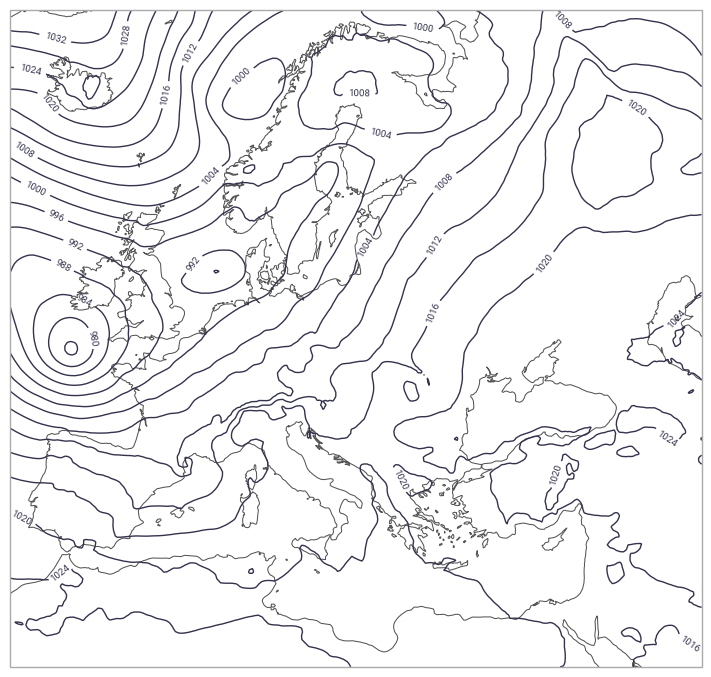

In [3]:
ekp.geo.contour(pressure, units="hPa", style="auto", domain="Europe")

`ekp.geo.plot` does the same thing but also chooses the *method*
(contour, filled contour, etc.) automatically:

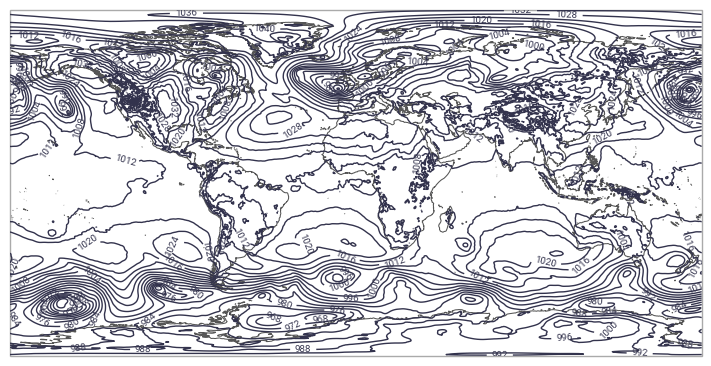

In [4]:
ekp.geo.plot(pressure, units="hPa")

### Lower-level API: `Map.contour`

`Map.contour` gives you more control.  You create the map first, then
add layers to it.  This makes it easy to combine contour lines with
other plot types.

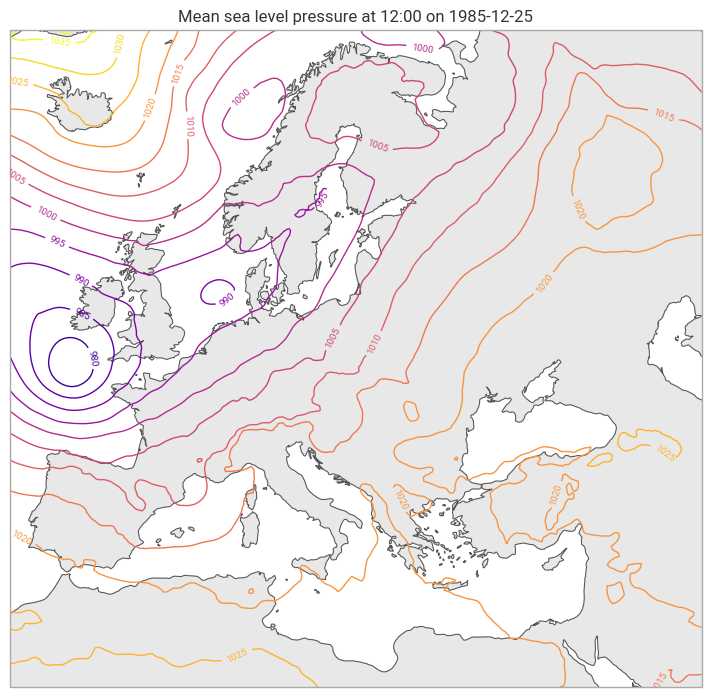

In [5]:
chart = ekp.Map(domain="Europe")
chart.contour(pressure, units="hPa")
chart.land()
chart.coastlines()
chart.title()
chart.show()

### Overlaying contour lines on a filled map

Because `Map.contour` and `Map.contourf` are separate calls you can
freely combine them on one map.

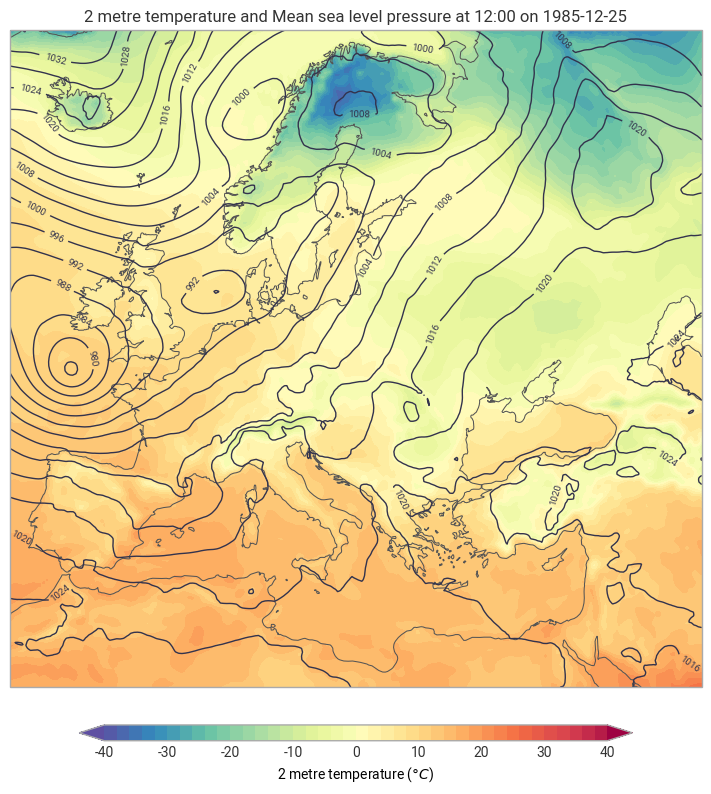

In [6]:
chart = ekp.Map(domain="Europe")
chart.contourf(temperature, units="celsius", style="auto")
chart.contour(pressure, units="hPa", style="auto")
chart.legend()
chart.land()
chart.coastlines()
chart.title()
chart.show()

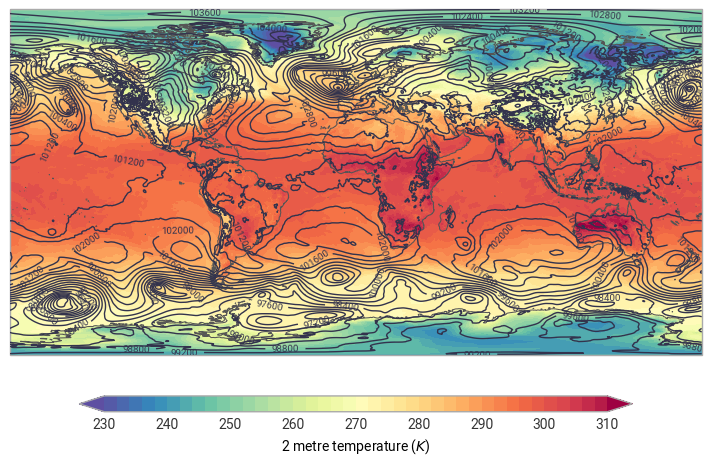

In [7]:
ekp.geo.plot(data, groupby="time.valid_datetime")

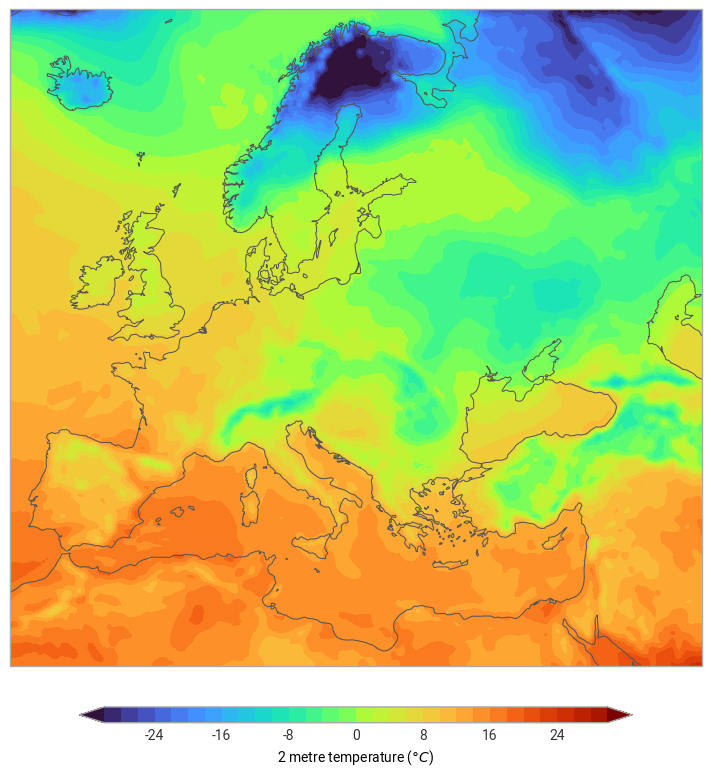

In [8]:
style = ekp.styles.Style(
    units="celsius",
    levels=range(-30, 31, 2),
    extend="both",
    cmap="turbo",
)

ekp.geo.plot(temperature, domain="Europe", style=style)

### What's next?

The next notebook covers how to control contour levels, line widths and
line styles.

In [15]:
chart = ekp.Map(domain=[-18, -10, 45, 50], size=(2, 2))
chart.contour(pressure, units="hPa", levels={"step": 4}, colors="#F94144")
chart.ax.set_frame_on(False)

chart.save("/Users/mavj/earthkit-1.0/earthkit-plots/docs/_static/thumbnails/contour-introduction.png")

In [22]:
chart = ekp.Map(domain=[-18, -10, 45, 50], size=(2, 2))
chart.contour(pressure, units="hPa", levels={"step": 4}, colors="#F94144", linestyles=["dashed", "solid"], linewidths=[0.5, 1])
chart.ax.set_frame_on(False)
chart.save("/Users/mavj/earthkit-1.0/earthkit-plots/docs/_static/thumbnails/contour-linestyles.png")

In [29]:
chart = ekp.Map(domain=[-18, -10, 45, 50], size=(2, 2))
chart.contour(pressure, units="hPa", levels={"step": 4}, cmap="turbo", linestyles=["dashed", "solid"], linewidths=[0.5, 1])
chart.ax.set_frame_on(False)
chart.save("/Users/mavj/earthkit-1.0/earthkit-plots/docs/_static/thumbnails/contour-styles.png")